# Paper Results From Excel Workbooks

This notebook mirrors `paper_results_experiments.ipynb`, but loads paper-result tables directly from `results/*.xlsx` instead of `artifacts/`.

Required inputs:
- `results/mvp_primary_db.xlsx`
- `results/intphys_primary_db.xlsx`
- optional `results/visualization_ready_results.xlsx` for reference

The temporal-control section is noted as unavailable because the Excel workbooks currently do not contain baseline-control sheets.


## Loaded Excel Sources

**Workbook blocks parsed from results/*.xlsx**

,Dataset,workbook,model_label,backbone,n_rows,probes
0,IntPhys2,intphys_primary_db.xlsx,LTX-Video,LTX-13B,84,"linear, mlp, temporal_attn"
1,IntPhys2,intphys_primary_db.xlsx,LTX-Video,LTX-2B,84,"linear, mlp, temporal_attn"
2,IntPhys2,intphys_primary_db.xlsx,V-JEPA,ViT-H/16,12,"linear, mlp, temporal_attn"
3,IntPhys2,intphys_primary_db.xlsx,V-JEPA,ViT-L/16,12,"linear, mlp, temporal_attn"
4,IntPhys2,intphys_primary_db.xlsx,V-JEPA 2,ViT-G/16,12,"linear, mlp, temporal_attn"
5,IntPhys2,intphys_primary_db.xlsx,V-JEPA 2,ViT-L/16,12,"linear, mlp, temporal_attn"
6,IntPhys2,intphys_primary_db.xlsx,V-JEPA 2.1,ViT-B/16,12,"linear, mlp, temporal_attn"
7,IntPhys2,intphys_primary_db.xlsx,V-JEPA 2.1,ViT-G/16,12,"linear, mlp, temporal_attn"
8,IntPhys2,intphys_primary_db.xlsx,V-JEPA 2.1,ViT-Gigantic/16,12,"linear, mlp, temporal_attn"
9,IntPhys2,intphys_primary_db.xlsx,V-JEPA 2.1,ViT-L/16,12,"linear, mlp, temporal_attn"


**Best layers selected from validation primary metric**

,Dataset,model_label,backbone,Probe,layer_label,best_validation_score,primary_score,test_accuracy_score
0,IntPhys2,V-JEPA,ViT-H/16,Linear,Layer 0.75,49.02,50.98,59.31
1,IntPhys2,V-JEPA 2,ViT-G/16,Linear,Final layer,39.22,41.18,58.82
2,IntPhys2,V-JEPA 2.1,ViT-Gigantic/16,Linear,Layer 0.75,33.33,23.53,52.94
3,IntPhys2,VideoMAE,ViT-H/16,Linear,Layer 0.5,41.18,35.29,58.33
4,IntPhys2,VideoMAE-v2,ViT-G/16,Linear,Layer 0.5,47.06,37.25,59.31
5,IntPhys2,LTX-Video,LTX-13B,Linear,noise_0.2_block_24,45.10,47.06,62.25
6,IntPhys2,V-JEPA,ViT-H/16,MLP,Layer 0.75,56.86,45.10,63.73
7,IntPhys2,V-JEPA 2,ViT-G/16,MLP,Final layer,41.18,47.06,59.31
8,IntPhys2,V-JEPA 2.1,ViT-Gigantic/16,MLP,Layer 0.75,45.10,39.22,57.35
9,IntPhys2,VideoMAE,ViT-H/16,MLP,Layer 0.75,39.22,35.29,59.80


## Experiment 1: Which model retains the most intuitive-physics understanding?

**Table 1A: Headline cross-benchmark comparison**

,Model family,Backbone,Pretraining objective,Best MVP layer,MVP pair consistency,MVP accuracy,Best IntPhys2 layer,IntPhys2 VOE,IntPhys2 accuracy
0,V-JEPA,ViT-H/16,self-supervised predictive video representation,Final layer,87.26,93.02,Layer 0.75,45.10,63.73
1,V-JEPA 2,ViT-G/16,self-supervised predictive video representation,Final layer,86.75,92.77,Final layer,47.06,59.31
2,V-JEPA 2.1,ViT-Gigantic/16,self-supervised predictive video representation,Layer 0.75,70.78,83.06,Layer 0.75,39.22,57.35
3,VideoMAE,ViT-H/16,masked video autoencoding,Layer 0.75,64.41,80.13,Layer 0.75,35.29,59.80
4,VideoMAE-v2,ViT-G/16,masked video autoencoding,Layer 0.5,66.13,80.43,Layer 0.5,47.06,56.37
5,LTX-Video,LTX-13B,video diffusion generation,noise_0.5_block_24,66.84,81.60,noise_0.2_block_24,47.06,61.76


**Table 1B: Compact leaderboard**

,Model,MVP primary metric,IntPhys2 primary metric,MVP rank,IntPhys2 rank
0,V-JEPA,87.26,45.10,1.00,4.00
1,V-JEPA 2,86.75,47.06,2.00,1.00
2,V-JEPA 2.1,70.78,39.22,3.00,5.00
3,VideoMAE,64.41,35.29,6.00,6.00
4,VideoMAE-v2,66.13,47.06,5.00,1.00
5,LTX-Video,66.84,47.06,4.00,1.00


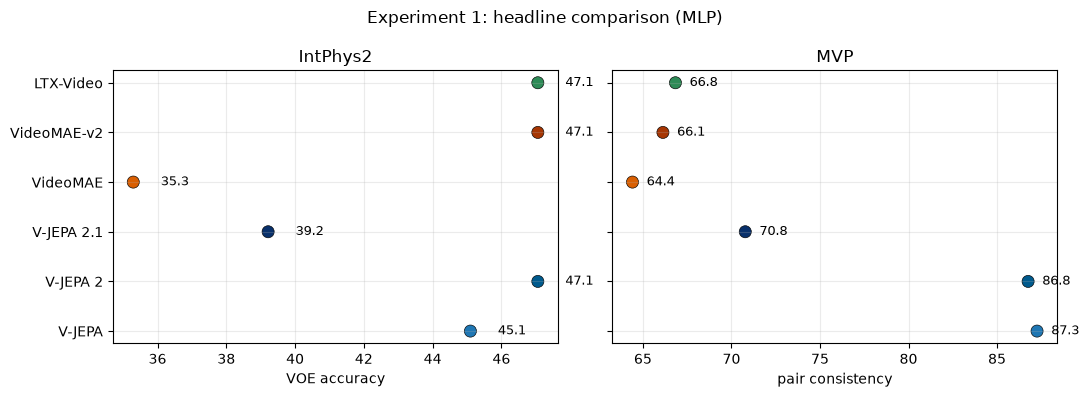

## Experiment 2: Where is the physics signal localized in depth?

**Table 2A: Best-layer summary**

,Model,Best layer on MVP,Best MVP score,Best layer on IntPhys2,Best IntPhys2 score
0,V-JEPA,Final layer,87.26,Layer 0.75,45.10
1,V-JEPA 2,Final layer,86.75,Final layer,47.06
2,V-JEPA 2.1,Layer 0.75,70.78,Layer 0.75,39.22
3,VideoMAE,Layer 0.75,64.41,Layer 0.75,35.29
4,VideoMAE-v2,Layer 0.5,66.13,Layer 0.5,47.06
5,LTX-Video,noise_0.5_block_24,66.84,noise_0.2_block_24,47.06


**Table 2B: Depth-profile summary**

,Model,MVP depth trend,IntPhys2 depth trend,Peak location type
0,V-JEPA,non-monotonic,non-monotonic,non-monotonic / non-monotonic
1,V-JEPA 2,late-rising,intermediate peak,late-rising / intermediate peak
2,V-JEPA 2.1,intermediate peak,non-monotonic,intermediate peak / non-monotonic
3,VideoMAE,non-monotonic,intermediate peak,non-monotonic / intermediate peak
4,VideoMAE-v2,intermediate peak,intermediate peak,intermediate peak / intermediate peak


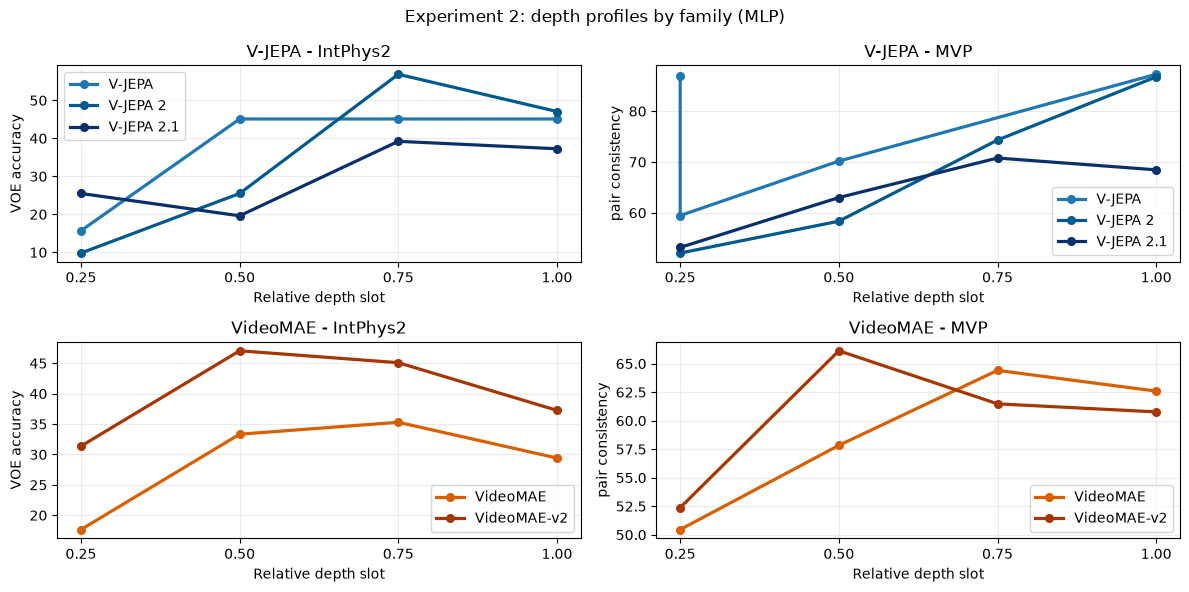

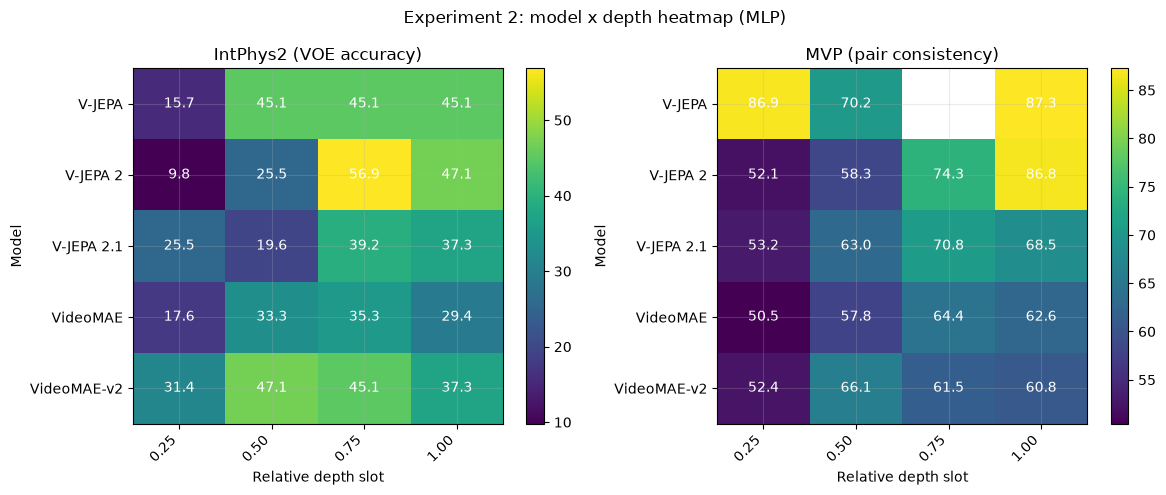

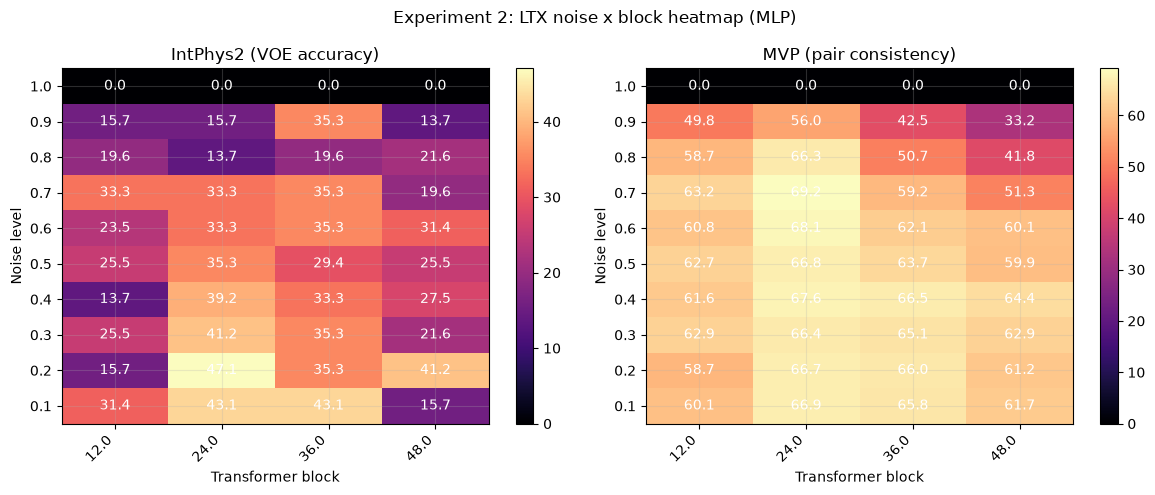

## Experiment 3: Which probe extracts the physics signal best?

**Table 3A: Best probe per model**

,Model,MVP Linear score,MVP MLP score,MVP Attentive score,Winning probe on MVP,IntPhys2 Linear score,IntPhys2 MLP score,IntPhys2 Attentive score,Winning probe on IntPhys2
0,V-JEPA,48.74,87.26,94.03,Attentive,50.98,45.10,66.67,Attentive
1,V-JEPA 2,48.53,86.75,92.82,Attentive,41.18,47.06,78.43,Attentive
2,V-JEPA 2.1,41.56,70.78,93.73,Attentive,23.53,39.22,60.78,Attentive
3,VideoMAE,37.51,64.41,92.01,Attentive,35.29,35.29,76.47,Attentive
4,VideoMAE-v2,37.71,66.13,91.10,Attentive,37.25,47.06,62.75,Attentive
5,LTX-Video,49.95,66.84,83.01,Attentive,47.06,47.06,43.14,Linear


**Table 3B: Gain over linear**

,Model,MVP MLP - linear,MVP attentive - linear,IntPhys2 MLP - linear,IntPhys2 attentive - linear
0,V-JEPA,38.52,45.30,-5.88,15.69
1,V-JEPA 2,38.22,44.29,5.88,37.25
2,V-JEPA 2.1,29.22,52.17,15.69,37.25
3,VideoMAE,26.90,54.50,0.00,41.18
4,VideoMAE-v2,28.41,53.39,9.80,25.49
5,LTX-Video,16.89,33.06,0.00,-3.92


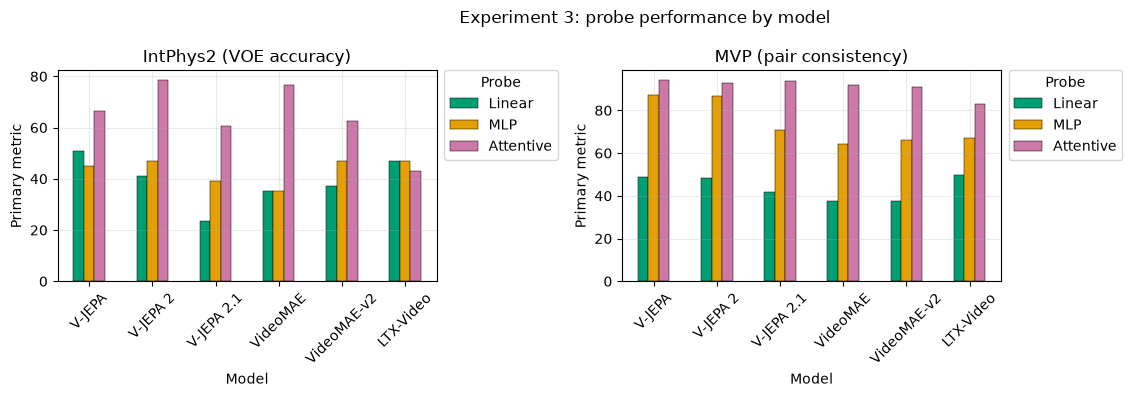

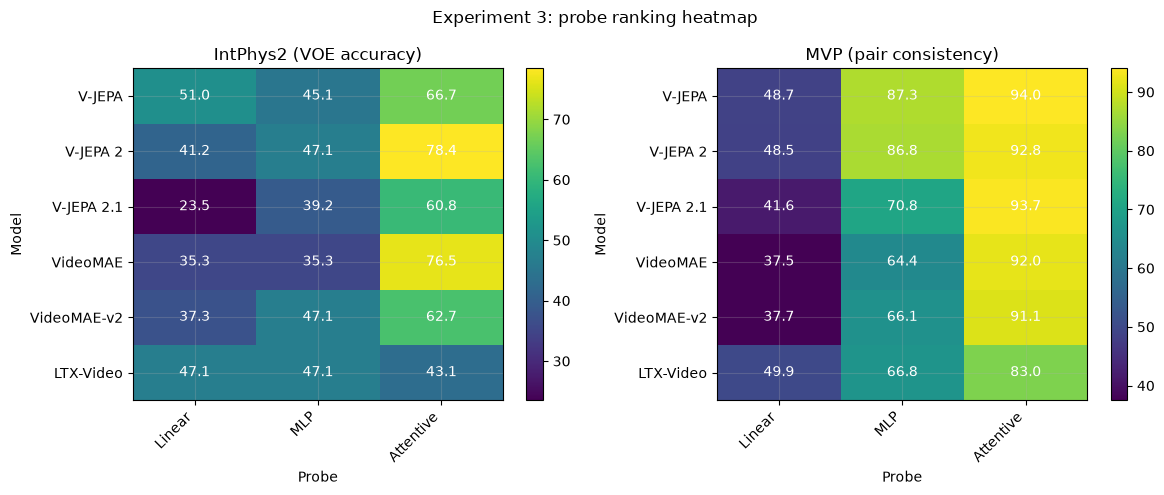

## Experiment 4: Temporal controls

The Excel workbooks in `results/` contain the primary probe/depth results, but no temporal-control baseline sheets. Temporal-control plots from the original artifact-backed notebook cannot be reconstructed from these Excel files alone.

In [3]:
from pathlib import Path
import os
import re
import sys

os.environ.setdefault('MPLCONFIGDIR', '/tmp/probe4physics_matplotlib')
os.environ.setdefault('XDG_CACHE_HOME', '/tmp/probe4physics_cache')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)
Path(os.environ['XDG_CACHE_HOME']).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        'This notebook requires matplotlib. Use the probe4physics-gpu environment or install matplotlib.'
    ) from exc
try:
    from IPython.display import Markdown, display
except ModuleNotFoundError:
    class Markdown(str):
        pass
    def display(obj):
        print(obj)

try:
    import seaborn as sns
except Exception:
    sns = None

pd.set_option('display.max_columns', 140)
pd.set_option('display.width', 180)
if sns is not None:
    sns.set_theme(style='whitegrid', context='notebook')
else:
    plt.rcParams.update({'axes.grid': True, 'grid.alpha': 0.25})

def find_repo_root(start=None):
    current = Path.cwd() if start is None else Path(start)
    for candidate in [current, *current.parents]:
        if (candidate / 'results').exists() and (candidate / 'run.py').exists():
            return candidate
    raise FileNotFoundError('Could not find repository root containing results/ and run.py')

REPO_ROOT = find_repo_root()
NOTEBOOK_DIR = REPO_ROOT / 'notebooks'
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))
import importlib
import plot_colors
importlib.reload(plot_colors)
from plot_colors import BACKBONE_COLORS, FAMILY_COLORS, MODEL_COLORS, PROBE_COLORS, PROBE_LABEL_COLORS

RESULTS_DIR = REPO_ROOT / 'results'
MVP_XLSX = RESULTS_DIR / 'mvp_primary_db.xlsx'
INTPHYS_XLSX = RESULTS_DIR / 'intphys_primary_db.xlsx'
VIS_XLSX = RESULTS_DIR / 'visualization_ready_results.xlsx'

HEADLINE_PROBE = 'mlp'
PROBE_ORDER = ['linear', 'mlp', 'temporal_attn']
PROBE_LABEL = {'linear': 'Linear', 'mlp': 'MLP', 'temporal_attn': 'Attentive'}
DATASET_ORDER = ['mvp', 'intphys2']
PANEL_DATASET_ORDER = ['intphys2', 'mvp']
DATASET_LABEL = {'mvp': 'MVP', 'intphys2': 'IntPhys2'}
PRIMARY_LABEL = {'mvp': 'pair consistency', 'intphys2': 'VOE accuracy'}

MODEL_ORDER = ['jepa_v1', 'jepa_v2', 'jepa_v2_1', 'videomae', 'videomae_v2', 'ltx_video']
MODEL_ORDER_INDEX = {key: idx for idx, key in enumerate(MODEL_ORDER)}
MODEL_META = {
    'jepa_v1': {'label': 'V-JEPA', 'family': 'V-JEPA', 'objective': 'self-supervised predictive video representation', 'paper_backbone': 'ViT-H/16'},
    'jepa_v2': {'label': 'V-JEPA 2', 'family': 'V-JEPA', 'objective': 'self-supervised predictive video representation', 'paper_backbone': 'ViT-G/16'},
    'jepa_v2_1': {'label': 'V-JEPA 2.1', 'family': 'V-JEPA', 'objective': 'self-supervised predictive video representation', 'paper_backbone': 'ViT-Gigantic/16'},
    'videomae': {'label': 'VideoMAE', 'family': 'VideoMAE', 'objective': 'masked video autoencoding', 'paper_backbone': 'ViT-H/16'},
    'videomae_v2': {'label': 'VideoMAE-v2', 'family': 'VideoMAE', 'objective': 'masked video autoencoding', 'paper_backbone': 'ViT-G/16'},
    'ltx_video': {'label': 'LTX-Video', 'family': 'Diffusion video model', 'objective': 'video diffusion generation', 'paper_backbone': 'LTX-13B'},
}
SHEET_TO_MODEL_KEY = {
    'V-JEPA': 'jepa_v1',
    'V-JEPA 2': 'jepa_v2',
    'V-JEPA 2.1': 'jepa_v2_1',
    'VideoMAE': 'videomae',
    'VideoMAE-v2': 'videomae_v2',
    'LTX-Video': 'ltx_video',
}

for path in [MVP_XLSX, INTPHYS_XLSX]:
    if not path.exists():
        raise FileNotFoundError(f'Missing required workbook: {path}')

def canonical_probe(value):
    text = str(value).strip().lower()
    if text in {'linear', 'lin'}:
        return 'linear'
    if text == 'mlp':
        return 'mlp'
    if text in {'attentive', 'temporal_attn', 'temporal attentive', 'temporal-attn'}:
        return 'temporal_attn'
    return text or None

def parse_ltx_slot(label):
    if label is None or pd.isna(label):
        return (np.nan, np.nan)
    match = re.search(r'noise_([0-9.]+)_block_(\d+)', str(label))
    if not match:
        return (np.nan, np.nan)
    return (float(match.group(1)), int(match.group(2)))

def relative_depth_from_label(label, fallback_rank=None, fallback_count=None):
    text = str(label).strip().lower()
    if text in {'final layer', 'last', 'final'}:
        return 1.0
    match = re.search(r'0\.(25|5|50|75)', text)
    if match:
        raw = match.group(0)
        return float(raw)
    if fallback_rank is not None and fallback_count not in (None, 0):
        return float(fallback_rank) / float(fallback_count)
    return np.nan

def parse_primary_workbook(path, dataset):
    frames = []
    xl = pd.ExcelFile(path)
    for sheet in xl.sheet_names:
        raw = xl.parse(sheet)
        cols = list(raw.columns)
        starts = [
            idx for idx, col in enumerate(cols)
            if not str(col).startswith('Unnamed') and 'primary metric' in str(col).lower()
        ]
        for start in starts:
            end = min(start + 11, len(cols))
            title = str(cols[start])
            backbone = title.split(' - primary metric:', 1)[0].strip()
            block = raw.iloc[:, start:end].copy()
            headers = [str(item).strip() for item in block.iloc[0].tolist()]
            block = block.iloc[1:].copy()
            block.columns = headers
            block = block.dropna(how='all')
            if 'Experiment' not in block.columns:
                continue
            block = block[block['Experiment'].notna()].copy()
            if block.empty:
                continue
            block['dataset'] = dataset
            block['workbook'] = path.name
            block['sheet'] = sheet
            block['model_key'] = SHEET_TO_MODEL_KEY.get(sheet, sheet)
            block['backbone'] = backbone
            frames.append(block)
    if not frames:
        raise ValueError(f'No parseable result blocks found in {path}')
    return pd.concat(frames, ignore_index=True, sort=False)

def load_excel_results():
    raw = pd.concat([
        parse_primary_workbook(MVP_XLSX, 'mvp'),
        parse_primary_workbook(INTPHYS_XLSX, 'intphys2'),
    ], ignore_index=True, sort=False)
    rename = {
        'Experiment': 'experiment',
        'Probe': 'probe_raw',
        'Layer': 'layer',
        'Layer Label': 'layer_label',
        'Selected LR': 'selected_lr',
        'Train Accuracy': 'train_accuracy',
        'Val Accuracy': 'val_accuracy',
        'Test Accuracy': 'test_accuracy',
        'Train Primary Metric': 'train_primary',
        'Val Primary Metric': 'val_primary',
        'Test Primary Metric': 'test_primary',
    }
    df = raw.rename(columns=rename).copy()
    df['probe'] = df['probe_raw'].map(canonical_probe)
    df['model_label'] = df['model_key'].map(lambda key: MODEL_META[key]['label'])
    df['family'] = df['model_key'].map(lambda key: MODEL_META[key]['family'])
    df['pretraining_objective'] = df['model_key'].map(lambda key: MODEL_META[key]['objective'])
    df['model_order'] = df['model_key'].map(MODEL_ORDER_INDEX).fillna(999).astype(int)
    for col in ['layer', 'selected_lr', 'train_accuracy', 'val_accuracy', 'test_accuracy', 'train_primary', 'val_primary', 'test_primary']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df['layer_label'] = df['layer_label'].astype('string')
    slots = df['layer_label'].map(parse_ltx_slot)
    df['ltx_noise_level'] = [slot[0] for slot in slots]
    df['ltx_block'] = [slot[1] for slot in slots]
    df['is_ltx'] = df['model_key'].eq('ltx_video')
    df['paper_backbone'] = df['model_key'].map(lambda key: MODEL_META[key]['paper_backbone'])
    df['is_paper_backbone'] = df['backbone'].eq(df['paper_backbone'])
    df = add_relative_depth(df)
    return df

def add_relative_depth(df):
    df = df.copy()
    df['relative_depth'] = np.nan
    for keys, group in df[~df['is_ltx']].groupby(['dataset', 'model_key', 'backbone', 'probe'], dropna=False):
        group = group.sort_values(['layer', 'layer_label'])
        count = len(group)
        for rank, idx in enumerate(group.index, start=1):
            df.loc[idx, 'relative_depth'] = relative_depth_from_label(df.loc[idx, 'layer_label'], rank, count)
    df.loc[df['is_ltx'], 'relative_depth'] = np.nan
    df['relative_depth_label'] = df['relative_depth'].map(lambda value: pd.NA if pd.isna(value) else f'{value:.2f}')
    return df

def paper_results(df):
    return df[df['is_paper_backbone']].copy()

def select_best_layers(df):
    candidates = df.dropna(subset=['val_primary']).copy()
    ordered = candidates.sort_values(['dataset', 'probe', 'model_key', 'backbone', 'val_primary', 'test_primary'])
    best = ordered.groupby(['dataset', 'probe', 'model_key', 'backbone'], group_keys=False).tail(1).copy()
    best['primary_score'] = best['test_primary']
    best['best_validation_score'] = best['val_primary']
    best['test_accuracy_score'] = best['test_accuracy']
    return best.sort_values(['dataset', 'probe', 'model_order']).reset_index(drop=True)

def show_table(df, title):
    display(Markdown(f'**{title}**'))
    display(df.style.format(precision=2, na_rep=''))

def row_for(df, dataset, model_key, probe=None):
    mask = df['dataset'].eq(dataset) & df['model_key'].eq(model_key)
    if probe is not None:
        mask &= df['probe'].eq(probe)
    rows = df[mask]
    if rows.empty:
        return None
    return rows.iloc[0]

def value_or_nan(row, column):
    if row is None or column not in row:
        return np.nan
    return row[column]

def layer_or_blank(row):
    if row is None:
        return pd.NA
    return row.get('layer_label', pd.NA)

def table_1a(best, probe=HEADLINE_PROBE):
    rows = []
    for model_key in MODEL_ORDER:
        meta = MODEL_META[model_key]
        mvp = row_for(best, 'mvp', model_key, probe)
        intphys = row_for(best, 'intphys2', model_key, probe)
        rows.append({
            'Model family': meta['label'],
            'Backbone': meta['paper_backbone'],
            'Pretraining objective': meta['objective'],
            'Best MVP layer': layer_or_blank(mvp),
            'MVP pair consistency': value_or_nan(mvp, 'primary_score'),
            'MVP accuracy': value_or_nan(mvp, 'test_accuracy_score'),
            'Best IntPhys2 layer': layer_or_blank(intphys),
            'IntPhys2 VOE': value_or_nan(intphys, 'primary_score'),
            'IntPhys2 accuracy': value_or_nan(intphys, 'test_accuracy_score'),
        })
    return pd.DataFrame(rows)

def table_1b(best, probe=HEADLINE_PROBE):
    rows = []
    for model_key in MODEL_ORDER:
        mvp = row_for(best, 'mvp', model_key, probe)
        intphys = row_for(best, 'intphys2', model_key, probe)
        rows.append({
            'model_key': model_key,
            'Model': MODEL_META[model_key]['label'],
            'MVP primary metric': value_or_nan(mvp, 'primary_score'),
            'IntPhys2 primary metric': value_or_nan(intphys, 'primary_score'),
        })
    out = pd.DataFrame(rows)
    out['MVP rank'] = out['MVP primary metric'].rank(ascending=False, method='min')
    out['IntPhys2 rank'] = out['IntPhys2 primary metric'].rank(ascending=False, method='min')
    return out.drop(columns='model_key')

def table_2a(best, probe=HEADLINE_PROBE):
    rows = []
    sub = best[best['probe'].eq(probe)]
    for model_key in MODEL_ORDER:
        mvp = row_for(sub, 'mvp', model_key)
        intphys = row_for(sub, 'intphys2', model_key)
        rows.append({
            'Model': MODEL_META[model_key]['label'],
            'Best layer on MVP': layer_or_blank(mvp),
            'Best MVP score': value_or_nan(mvp, 'primary_score'),
            'Best layer on IntPhys2': layer_or_blank(intphys),
            'Best IntPhys2 score': value_or_nan(intphys, 'primary_score'),
        })
    return pd.DataFrame(rows)

def classify_trend(values, tolerance=2.0):
    y = pd.Series(values).dropna().to_numpy(dtype=float)
    if len(y) < 3:
        return 'insufficient'
    if np.nanmax(y) - np.nanmin(y) <= tolerance:
        return 'flat'
    peak_idx = int(np.nanargmax(y))
    if peak_idx == len(y) - 1 and np.all(np.diff(y) >= -tolerance):
        return 'late-rising'
    if 0 < peak_idx < len(y) - 1 and y[peak_idx] - y[-1] > tolerance:
        return 'intermediate peak'
    return 'non-monotonic'

def table_2b(results, probe=HEADLINE_PROBE):
    rows = []
    sub = results[(results['probe'].eq(probe)) & (~results['is_ltx'])].copy()
    for model_key in [key for key in MODEL_ORDER if key != 'ltx_video']:
        row = {'Model': MODEL_META[model_key]['label']}
        labels = []
        for dataset in DATASET_ORDER:
            series = sub[(sub['dataset'].eq(dataset)) & (sub['model_key'].eq(model_key))].sort_values('relative_depth')['test_primary']
            trend = classify_trend(series)
            row[f'{DATASET_LABEL[dataset]} depth trend'] = trend
            labels.append(trend)
        row['Peak location type'] = ' / '.join(labels)
        rows.append(row)
    return pd.DataFrame(rows)

def table_3a(best):
    rows = []
    for model_key in MODEL_ORDER:
        row = {'Model': MODEL_META[model_key]['label']}
        for dataset in DATASET_ORDER:
            scores = {}
            for probe in PROBE_ORDER:
                score = value_or_nan(row_for(best, dataset, model_key, probe), 'primary_score')
                scores[probe] = score
                row[f'{DATASET_LABEL[dataset]} {PROBE_LABEL[probe]} score'] = score
            valid = {probe: score for probe, score in scores.items() if pd.notna(score)}
            row[f'Winning probe on {DATASET_LABEL[dataset]}'] = PROBE_LABEL[max(valid, key=valid.get)] if valid else pd.NA
        rows.append(row)
    return pd.DataFrame(rows)

def table_3b(best):
    rows = []
    for model_key in MODEL_ORDER:
        row = {'Model': MODEL_META[model_key]['label']}
        for dataset in DATASET_ORDER:
            linear = value_or_nan(row_for(best, dataset, model_key, 'linear'), 'primary_score')
            mlp = value_or_nan(row_for(best, dataset, model_key, 'mlp'), 'primary_score')
            attn = value_or_nan(row_for(best, dataset, model_key, 'temporal_attn'), 'primary_score')
            row[f'{DATASET_LABEL[dataset]} MLP - linear'] = mlp - linear if pd.notna(mlp) and pd.notna(linear) else np.nan
            row[f'{DATASET_LABEL[dataset]} attentive - linear'] = attn - linear if pd.notna(attn) and pd.notna(linear) else np.nan
        rows.append(row)
    return pd.DataFrame(rows)

def draw_heatmap(pivot, title, ax, cmap='viridis'):
    if pivot.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.set_title(title)
        ax.set_axis_off()
        return
    if sns is not None:
        sns.heatmap(pivot, annot=True, fmt='.1f', cmap=cmap, ax=ax, cbar=True)
    else:
        values = pivot.to_numpy(dtype=float)
        im = ax.imshow(values, aspect='auto', cmap=cmap)
        ax.figure.colorbar(im, ax=ax)
        ax.set_xticks(np.arange(len(pivot.columns)), labels=pivot.columns, rotation=45, ha='right')
        ax.set_yticks(np.arange(len(pivot.index)), labels=pivot.index)
        for i in range(values.shape[0]):
            for j in range(values.shape[1]):
                if np.isfinite(values[i, j]):
                    ax.text(j, i, f'{values[i, j]:.1f}', ha='center', va='center', color='white')
    ax.set_title(title)

def plot_headline_dot(best, probe=HEADLINE_PROBE):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
    model_labels = [MODEL_META[key]['label'] for key in MODEL_ORDER]
    y = np.arange(len(MODEL_ORDER))
    for ax, dataset in zip(axes, PANEL_DATASET_ORDER):
        scores = [value_or_nan(row_for(best, dataset, key, probe), 'primary_score') for key in MODEL_ORDER]
        colors = [MODEL_COLORS.get(key, '#777777') for key in MODEL_ORDER]
        ax.scatter(scores, y, s=76, c=colors, edgecolor='black', linewidth=0.45)
        for score, yi in zip(scores, y):
            if pd.notna(score):
                ax.text(score + 0.8, yi, f'{score:.1f}', va='center', fontsize=9)
        ax.set_yticks(y, labels=model_labels)
        ax.invert_yaxis()
        ax.set_xlabel(PRIMARY_LABEL[dataset])
        ax.set_title(DATASET_LABEL[dataset])
    fig.suptitle(f'Experiment 1: headline comparison ({PROBE_LABEL[probe]})')
    fig.tight_layout()
    return fig

def plot_depth_by_family(results, probe=HEADLINE_PROBE):
    sub = results[(results['probe'].eq(probe)) & (~results['is_ltx'])].dropna(subset=['relative_depth', 'test_primary']).copy()
    families = [family for family in ['V-JEPA', 'VideoMAE'] if family in set(sub['family'])]
    fig, axes = plt.subplots(len(families), 2, figsize=(12, max(3, 3 * len(families))), squeeze=False)
    for row_idx, family in enumerate(families):
        for col_idx, dataset in enumerate(PANEL_DATASET_ORDER):
            ax = axes[row_idx][col_idx]
            ds = sub[(sub['family'].eq(family)) & (sub['dataset'].eq(dataset))]
            for model_key, model_df in ds.groupby('model_key'):
                model_df = model_df.sort_values('relative_depth')
                ax.plot(
                    model_df['relative_depth'],
                    model_df['test_primary'],
                    marker='o',
                    markersize=5.5,
                    linestyle='-',
                    color=MODEL_COLORS.get(model_key, FAMILY_COLORS.get(family, '#777777')),
                    linewidth=2.3,
                    label=MODEL_META[model_key]['label'],
                )
            ax.set_title(f'{family} - {DATASET_LABEL[dataset]}')
            ax.set_xlabel('Relative depth slot')
            ax.set_ylabel(PRIMARY_LABEL[dataset])
            ax.set_xticks([0.25, 0.50, 0.75, 1.00])
            ax.legend(loc='best')
    fig.suptitle(f'Experiment 2: depth profiles by family ({PROBE_LABEL[probe]})')
    fig.tight_layout()
    return fig

def plot_depth_heatmap(results, probe=HEADLINE_PROBE):
    sub = results[(results['probe'].eq(probe)) & (~results['is_ltx'])].dropna(subset=['relative_depth_label', 'test_primary']).copy()
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, dataset in zip(axes, PANEL_DATASET_ORDER):
        ds = sub[sub['dataset'].eq(dataset)].copy()
        ds['Model'] = ds['model_key'].map(lambda key: MODEL_META[key]['label'])
        depth_cols = sorted(ds['relative_depth_label'].dropna().unique(), key=lambda value: float(value))
        model_rows = [MODEL_META[key]['label'] for key in MODEL_ORDER if key != 'ltx_video']
        pivot = ds.pivot_table(index='Model', columns='relative_depth_label', values='test_primary', aggfunc='max').reindex(index=model_rows, columns=depth_cols)
        draw_heatmap(pivot, f'{DATASET_LABEL[dataset]} ({PRIMARY_LABEL[dataset]})', ax)
        ax.set_xlabel('Relative depth slot')
        ax.set_ylabel('Model')
    fig.suptitle(f'Experiment 2: model x depth heatmap ({PROBE_LABEL[probe]})')
    fig.tight_layout()
    return fig

def plot_ltx_heatmap(results, probe=HEADLINE_PROBE):
    sub = results[(results['probe'].eq(probe)) & (results['model_key'].eq('ltx_video'))].dropna(subset=['ltx_noise_level', 'ltx_block', 'test_primary']).copy()
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, dataset in zip(axes, PANEL_DATASET_ORDER):
        ds = sub[sub['dataset'].eq(dataset)].copy()
        noise = sorted(ds['ltx_noise_level'].dropna().unique(), reverse=True)
        blocks = sorted(ds['ltx_block'].dropna().unique())
        pivot = ds.pivot_table(index='ltx_noise_level', columns='ltx_block', values='test_primary', aggfunc='max').reindex(index=noise, columns=blocks)
        draw_heatmap(pivot, f'{DATASET_LABEL[dataset]} ({PRIMARY_LABEL[dataset]})', ax, cmap='magma')
        ax.set_xlabel('Transformer block')
        ax.set_ylabel('Noise level')
    fig.suptitle(f'Experiment 2: LTX noise x block heatmap ({PROBE_LABEL.get(probe, probe)})')
    fig.tight_layout()
    return fig

def plot_probe_performance_bars(best):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
    for ax, dataset in zip(axes, PANEL_DATASET_ORDER):
        ds = best[best['dataset'].eq(dataset)].copy()
        ds['Model'] = ds['model_key'].map(lambda key: MODEL_META[key]['label'])
        ds['Probe'] = ds['probe'].map(PROBE_LABEL)
        model_rows = [MODEL_META[key]['label'] for key in MODEL_ORDER]
        probe_cols = [PROBE_LABEL[key] for key in PROBE_ORDER]
        plot_df = ds.pivot_table(index='Model', columns='Probe', values='primary_score', aggfunc='max').reindex(index=model_rows, columns=probe_cols)
        plot_df.plot(
            kind='bar',
            ax=ax,
            color=[PROBE_COLORS[p] for p in PROBE_ORDER],
            edgecolor='black',
            linewidth=0.35,
        )
        ax.set_title(f'{DATASET_LABEL[dataset]} ({PRIMARY_LABEL[dataset]})')
        ax.set_ylabel('Primary metric')
        ax.set_xlabel('Model')
        ax.tick_params(axis='x', rotation=45)
        ax.legend(title='Probe', loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
    fig.suptitle('Experiment 3: probe performance by model')
    fig.tight_layout(rect=[0, 0, 0.88, 1])
    return fig

def plot_probe_heatmap(best):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, dataset in zip(axes, PANEL_DATASET_ORDER):
        sub = best[best['dataset'].eq(dataset)].copy()
        sub['Model'] = sub['model_key'].map(lambda key: MODEL_META[key]['label'])
        sub['Probe'] = sub['probe'].map(PROBE_LABEL)
        model_rows = [MODEL_META[key]['label'] for key in MODEL_ORDER]
        probe_cols = [PROBE_LABEL[key] for key in PROBE_ORDER]
        pivot = sub.pivot_table(index='Model', columns='Probe', values='primary_score', aggfunc='max').reindex(index=model_rows, columns=probe_cols)
        draw_heatmap(pivot, f'{DATASET_LABEL[dataset]} ({PRIMARY_LABEL[dataset]})', ax, cmap='crest' if sns is not None else 'viridis')
        ax.set_xlabel('Probe')
        ax.set_ylabel('Model')
    fig.suptitle('Experiment 3: probe ranking heatmap')
    fig.tight_layout()
    return fig

all_results = load_excel_results()
results = paper_results(all_results)
best_layers = select_best_layers(results)

source_summary = (
    all_results.groupby(['dataset', 'workbook', 'model_label', 'backbone'], as_index=False)
    .agg(n_rows=('test_primary', 'size'), probes=('probe', lambda s: ', '.join(sorted(s.dropna().unique()))))
)
source_summary['Dataset'] = source_summary['dataset'].map(DATASET_LABEL)
source_summary = source_summary[['Dataset', 'workbook', 'model_label', 'backbone', 'n_rows', 'probes']]

display(Markdown('## Loaded Excel Sources'))
show_table(source_summary, 'Workbook blocks parsed from results/*.xlsx')
show_table(
    best_layers[['dataset', 'model_label', 'backbone', 'probe', 'layer_label', 'best_validation_score', 'primary_score', 'test_accuracy_score']]
    .assign(Dataset=lambda d: d['dataset'].map(DATASET_LABEL), Probe=lambda d: d['probe'].map(PROBE_LABEL))
    [['Dataset', 'model_label', 'backbone', 'Probe', 'layer_label', 'best_validation_score', 'primary_score', 'test_accuracy_score']],
    'Best layers selected from validation primary metric',
)

display(Markdown('## Experiment 1: Which model retains the most intuitive-physics understanding?'))
show_table(table_1a(best_layers, HEADLINE_PROBE), 'Table 1A: Headline cross-benchmark comparison')
show_table(table_1b(best_layers, HEADLINE_PROBE), 'Table 1B: Compact leaderboard')
plot_headline_dot(best_layers, HEADLINE_PROBE)
plt.show()

display(Markdown('## Experiment 2: Where is the physics signal localized in depth?'))
show_table(table_2a(best_layers, HEADLINE_PROBE), 'Table 2A: Best-layer summary')
show_table(table_2b(results, HEADLINE_PROBE), 'Table 2B: Depth-profile summary')
plot_depth_by_family(results, HEADLINE_PROBE)
plot_depth_heatmap(results, HEADLINE_PROBE)
plot_ltx_heatmap(results, HEADLINE_PROBE)
plt.show()

display(Markdown('## Experiment 3: Which probe extracts the physics signal best?'))
show_table(table_3a(best_layers), 'Table 3A: Best probe per model')
show_table(table_3b(best_layers), 'Table 3B: Gain over linear')
plot_probe_performance_bars(best_layers)
plot_probe_heatmap(best_layers)
plt.show()

display(Markdown('## Experiment 4: Temporal controls'))
display(Markdown(
    'The Excel workbooks in `results/` contain the primary probe/depth results, but no temporal-control baseline sheets. '
    'Temporal-control plots from the original artifact-backed notebook cannot be reconstructed from these Excel files alone.'
))
